https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

import torch

from msi import LikelihoodFlow
from msi.flow_conductor import architecture
from msi.utils import input_output
from msfm.utils import prior, parameters, files, logger

24-01-23 00:27:44   imports.py INF   Setting up healpy to run on 256 CPUs 


# load network predictions

### v4

In [3]:
# # combined probes
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

# # all parameters
# model_dir = "2023-08-31_03-29-47_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v6

#### lensing only

In [4]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"

# delta loss
model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"

# likelihood loss
# model_dir = "likelihood/2024-01-22_05-29-26_resnet_vanilla"

n_steps = 100000
params = ["Om", "s8", "w0", "Aia", "n_Aia"]

#### clustering only

#### combined probes

### general

In [6]:
# dataset
fidu_preds, grid_preds, grid_cosmos = input_output.get_reshaped_network_preds(
    base_dir, model_dir, n_steps, n_params=len(params)
)

# output directory and file names
out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_flow"

24-01-23 00:28:05 input_output INF   Array shapes: 
24-01-23 00:28:05 input_output INF   fiducial/vali/pred = (4, 5) 
24-01-23 00:28:05 input_output INF   fiducial/vali/i_example = (4,) 
24-01-23 00:28:05 input_output INF   fiducial/vali/i_noise = (4,) 
24-01-23 00:28:05 input_output INF   grid/pred          = (2500, 48, 5) 
24-01-23 00:28:05 input_output INF   grid/cosmo         = (2500, 5) 
24-01-23 00:28:05 input_output INF   grid/i_example     = (2500, 48) 
24-01-23 00:28:05 input_output INF   grid/i_noise       = (2500, 48) 
24-01-23 00:28:05 input_output INF   grid/i_sobol       = (2500,) 


24-01-23 00:28:05 input_output INF   Shapes after concatenation and selection: 
24-01-23 00:28:05 input_output INF   fidu_preds  = (4, 5) 
24-01-23 00:28:05 input_output INF   grid_preds  = (120000, 5) 
24-01-23 00:28:05 input_output INF   grid_cosmos = (120000, 5) 


### observation

In [6]:
i_obs = 0
# i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))

print(f"Using the example index {i_obs}")
obs_pred = fidu_preds[i_obs]

Using the example index 0


# likelihood Flow $p(x|\theta)$

In [7]:
# input dimensions
x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 64

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=5,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 20,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

flow = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    label=label
)

24-01-22 08:51:13 likelihood_f INF   Initialized the normalizing flow 
24-01-22 08:51:13 likelihood_f INF   Running on device cuda with default float torch.float32 


In [8]:
# flow = LikelihoodFlow(params, conf, out_dir=out_dir, label=label)

### training

100%|████████████████████████████|   | 100/100 [08:57<00:00,  5.38s/it]       lr: 1.00E-06, train: -8.70, vali: -8.47: 
24-01-22 09:00:14 likelihood_f INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/delta/2024-01-12_19-35-59_resnet_vanilla/model100000_flow.pt 


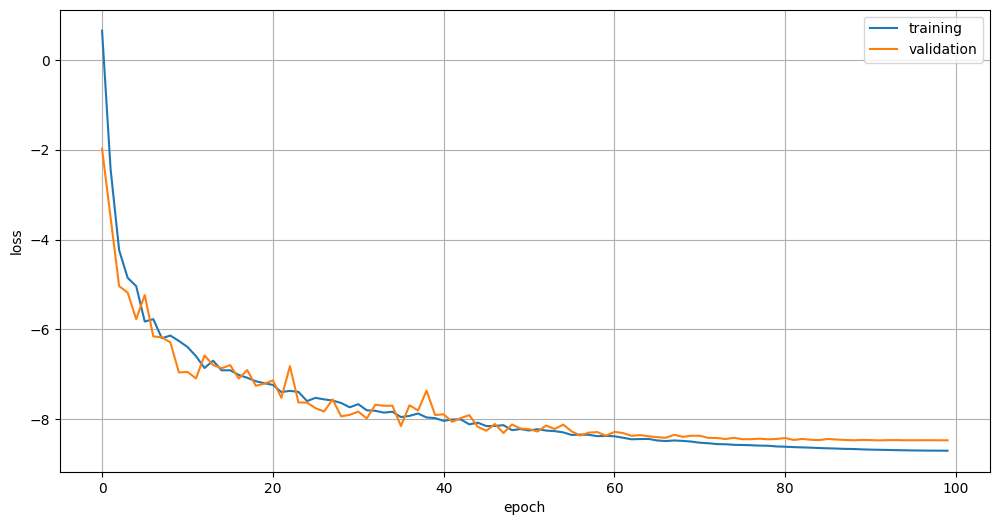

In [9]:
flow.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=100,
    # dataset
    batch_size=1024,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-3,
    weight_decay=0.0,
    clip_by_global_norm=100.0,
    learning_rate_min=1e-6,
    # early stopping
    n_patience_epochs=10,
    min_delta=0.0,
    save_model=True,
)

### MCMC

In [10]:
posterior_samples = flow.sample_posterior(
    obs_pred,
)

24-01-22 09:00:16      mcmc.py INF   Initial values in prior: True 
24-01-22 09:00:16      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-01-22 09:00:23      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [00:31<00:00, 15.74it/s]

24-01-22 09:00:55      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/delta/2024-01-12_19-35-59_resnet_vanilla/chain_100000_flow.npy 


### plotting

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-01-22 09:01:00  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v6/lensing_only/delta/2024-01-12_19-35-59_resnet_vanilla/contours_100000_flow.png 


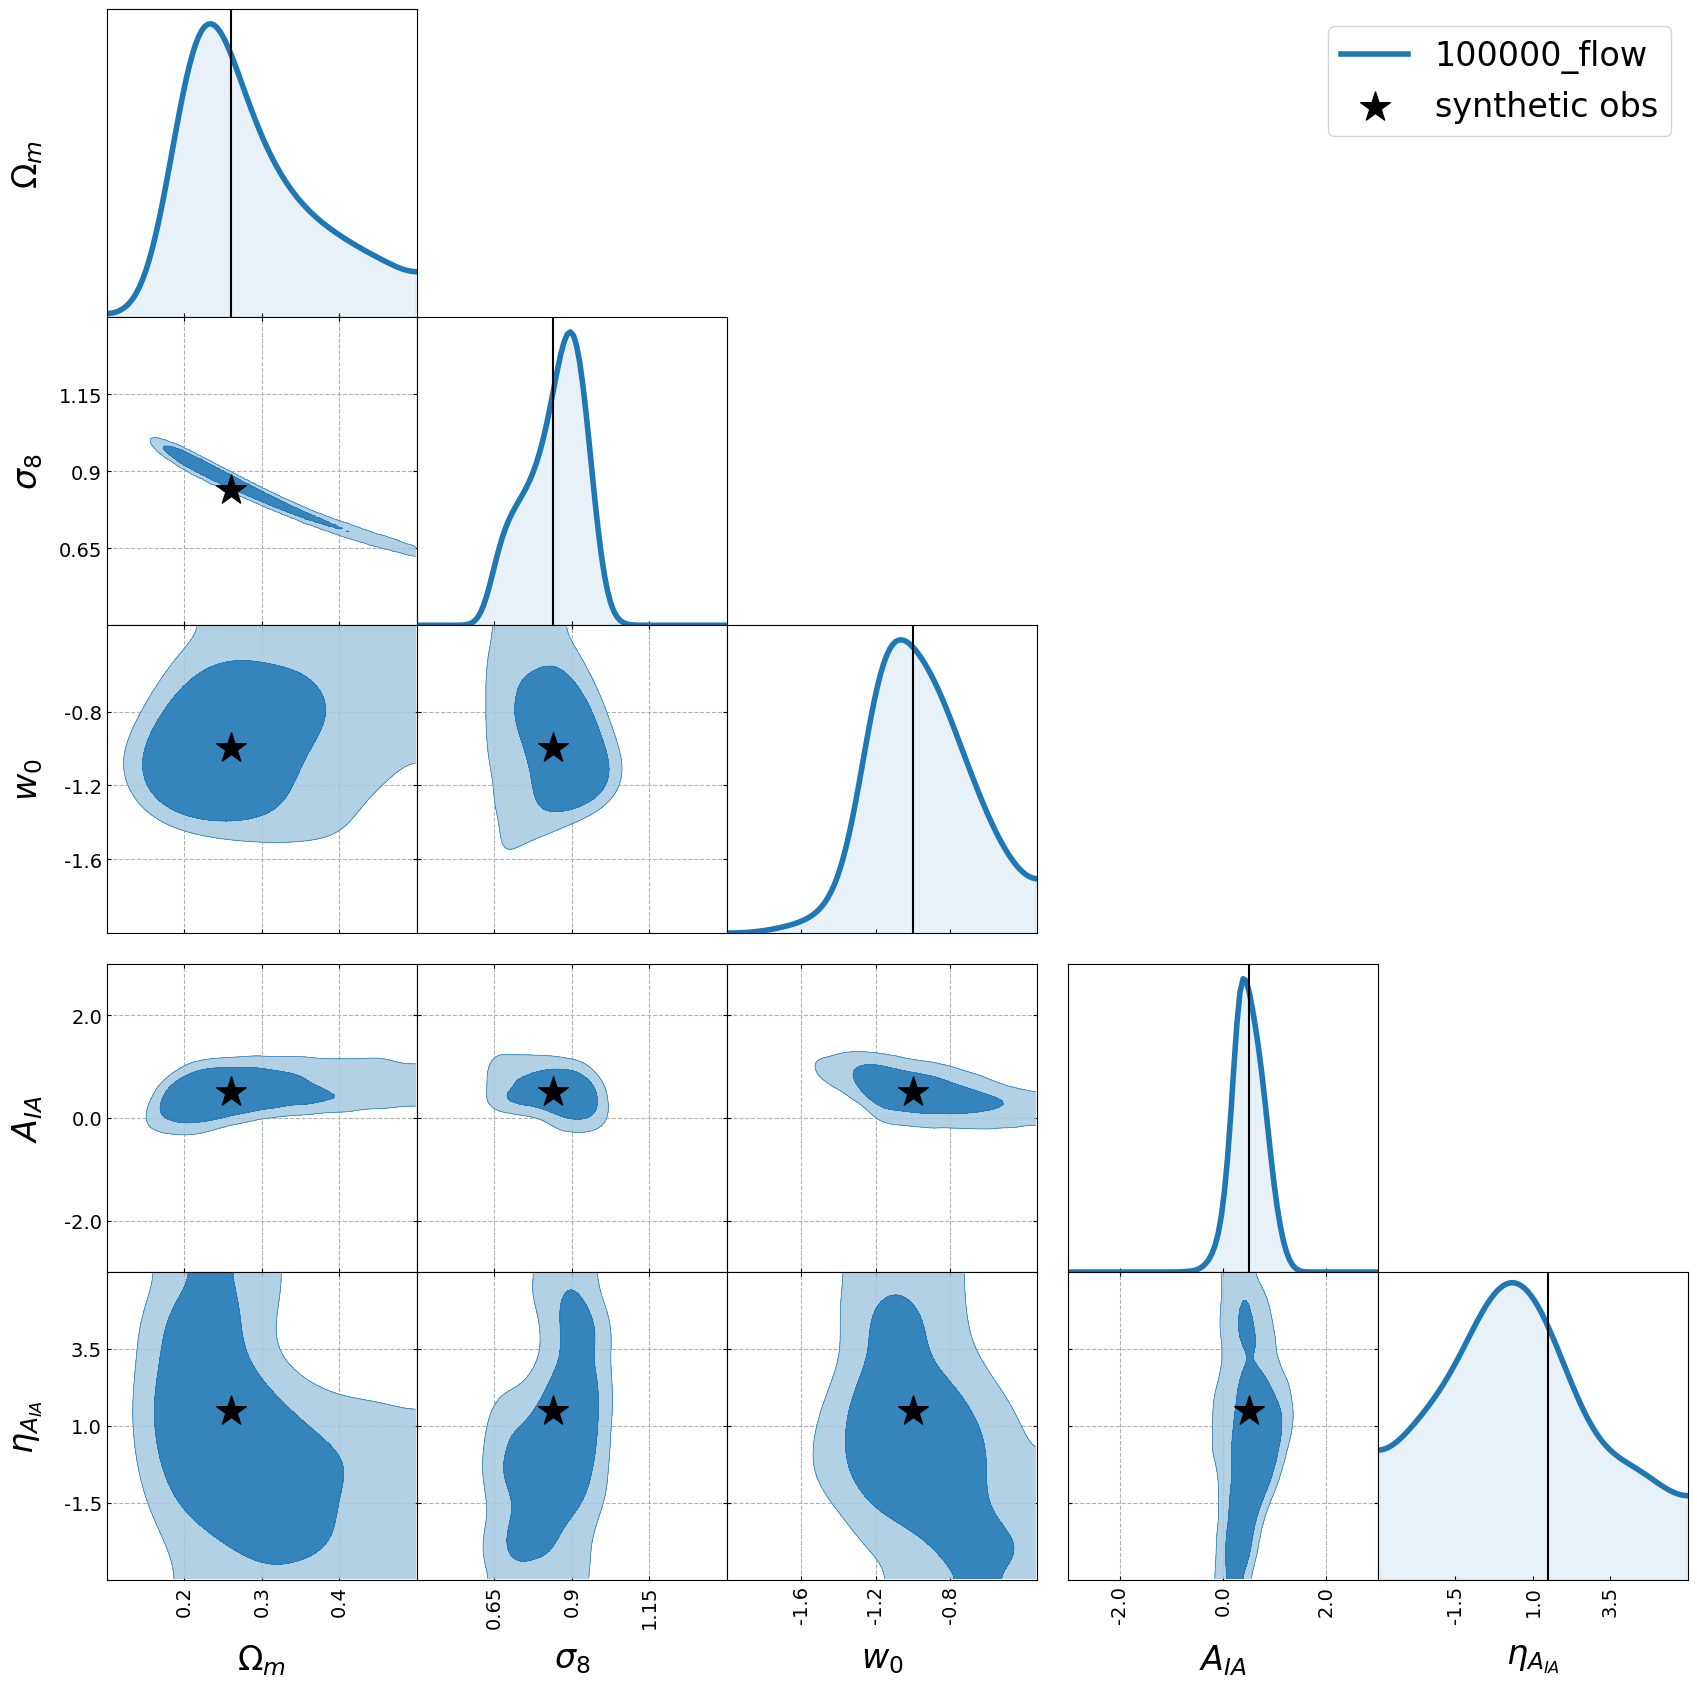

In [11]:
flow.plot_contours(
    posterior_samples,
)